# Renewables and price: energy-market EDA

The exploratory analysis a power quant does on day one with a new market dataset: turn
weather into generation, look at what is left for the thermal fleet (residual load), and
find out how price responds to it.

Each step is shown first on a handful of numbers, then on the two years of hourly data.

**What's in here**
1. wind: a power curve, capacity factor, duration curve, fleet smoothing, ramps, forecast-error amplification
2. solar and the duck curve of net load
3. residual load and price: the merit-order curve, price sensitivity, 2022 vs 2023
4. price statistics: tails, spikes, negative prices, hourly profile, blocks and spreads
5. weather sensitivity of demand
6. data-quality checks specific to market data
7. checklist

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.index = df.index.tz_convert("Europe/London")    # delivery periods are local for block definitions
df["hour"] = df.index.hour
df["month"] = df.index.month
df["year"] = df.index.year
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,hour,month,year
time,,,,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83,0,1,2022
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21,1,1,2022
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71,2,1,2022


## 1. Wind: from wind speed to power

A turbine gives nothing below the cut-in speed (3 m/s), rises roughly with the cube of wind
speed up to the rated speed (12 m/s), stays at full output, and shuts down above cut-out
(25 m/s). Write the rule out in steps for five wind speeds:

In [2]:
cut_in, rated, cut_out = 3.0, 12.0, 25.0
speeds = pd.Series([2.0, 5.0, 8.0, 12.0, 26.0], name="wind_ms")
fraction_of_ramp = (speeds - cut_in) / (rated - cut_in)           # 0 at cut-in, 1 at rated
cubic = fraction_of_ramp ** 3
pd.DataFrame({"wind_ms": speeds, "fraction_of_ramp": fraction_of_ramp, "cubic": cubic}).round(3)

,wind_ms,fraction_of_ramp,cubic
0,2.0,-0.111,-0.001
1,5.0,0.222,0.011
2,8.0,0.556,0.171
3,12.0,1.000,1.000
4,26.0,2.556,16.690


In [3]:
output = cubic.copy()
output[speeds < cut_in] = 0.0        # below cut-in: nothing
output[speeds >= rated] = 1.0        # at or above rated: full
output[speeds >= cut_out] = 0.0      # above cut-out: shut down
pd.DataFrame({"wind_ms": speeds, "output_fraction": output}).round(3)

,wind_ms,output_fraction
0,2.0,0.000
1,5.0,0.011
2,8.0,0.171
3,12.0,1.000
4,26.0,0.000


2 m/s → 0 (below cut-in), 5 m/s → 1% (the cube of a small number), 8 m/s → 17%, 12 m/s →
100%, 26 m/s → 0 (cut-out). Wrapped as a function:

In [4]:
def power_curve(v, cut_in=3.0, rated=12.0, cut_out=25.0):
    v = np.asarray(v, dtype=float)
    cubic = ((v - cut_in) / (rated - cut_in)) ** 3
    out = np.where(v < cut_in, 0.0, np.where(v < rated, cubic, 1.0))
    return np.where(v >= cut_out, 0.0, out)

v = np.arange(0, 27)
pd.DataFrame({"wind_ms": v, "output_fraction": power_curve(v).round(3)}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
wind_ms,0.0,1.0,2.0,3.0,4.000,5.000,6.000,7.000,8.000,9.000,10.000,11.000,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0
output_fraction,0.0,0.0,0.0,0.0,0.001,0.011,0.037,0.088,0.171,0.296,0.471,0.702,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0


### Capacity factor

Capacity factor = average output ÷ capacity. Four hours of a 100 MW fleet:

In [5]:
mw = pd.Series([0, 20, 80, 100], index=["h1", "h2", "h3", "h4"])
print("average MW:", mw.mean(), " capacity 100 MW  -> capacity factor", mw.mean() / 100)

average MW: 50.0  capacity 100 MW  -> capacity factor 0.5


In [6]:
WIND_CAP_MW = 10_000
df["wind_mw"] = WIND_CAP_MW * power_curve(df["wind_ms"])
print("fleet capacity factor, two years:", round(df["wind_mw"].mean() / WIND_CAP_MW, 3))

fleet capacity factor, two years: 0.208


In [7]:
cf_month = df.groupby("month")["wind_mw"].mean() / WIND_CAP_MW
cf_month.round(3).rename("cf_by_month").to_frame().T

month,1,2,3,4,5,6,7,8,9,10,11,12
cf_by_month,0.297,0.187,0.188,0.267,0.161,0.225,0.173,0.185,0.244,0.201,0.177,0.192


### Duration curve

Sort output from highest to lowest. The curve answers "how many hours a year is the fleet
above X MW?" with no time structure at all. Six values:

In [8]:
mw = pd.Series([30, 0, 100, 60, 0, 10])
sorted_mw = mw.sort_values(ascending=False).reset_index(drop=True)
share_of_hours = (sorted_mw.index + 1) / len(sorted_mw)
pd.DataFrame({"MW (sorted)": sorted_mw, "share_of_hours": share_of_hours.round(2)})

,MW (sorted),share_of_hours
0,100,0.17
1,60,0.33
2,30,0.50
3,10,0.67
4,0,0.83
5,0,1.00


Read it as: "for 33% of hours the output is at least 60 MW; for 33% of hours it is zero."

top 10 % of hours: fleet above 5927 MW
top 50 % of hours: fleet above 1031 MW
top 90 % of hours: fleet above 20 MW
hours at zero output: 3.7 %


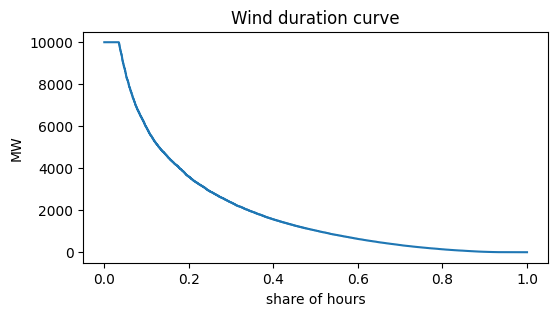

In [9]:
duration = np.sort(df["wind_mw"].values)[::-1]
share = np.arange(1, len(duration) + 1) / len(duration)
for q in [0.1, 0.5, 0.9]:
    print("top", int(q * 100), "% of hours: fleet above", round(duration[int(q * len(duration)) - 1]), "MW")
print("hours at zero output:", round((df["wind_mw"] == 0).mean() * 100, 1), "%")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(share, duration)
ax.set_xlabel("share of hours"); ax.set_ylabel("MW"); ax.set_title("Wind duration curve")
plt.show()

### Why a fleet is smoother than one turbine

Two sites see the same national wind plus their own local noise. Averaging them cancels part
of the noise. Four hours:

In [10]:
site_a = pd.Series([0.0, 1.0, 0.0, 1.0])
site_b = pd.Series([1.0, 0.0, 1.0, 0.0])
fleet = (site_a + site_b) / 2
pd.DataFrame({"site_a": site_a, "site_b": site_b, "fleet_average": fleet})

,site_a,site_b,fleet_average
0,0.0,1.0,0.5
1,1.0,0.0,0.5
2,0.0,1.0,0.5
3,1.0,0.0,0.5


In [11]:
print("std of site a:", round(site_a.std(), 3), " std of the fleet:", round(fleet.std(), 3))

std of site a: 0.577  std of the fleet: 0.0


Simulated with five sites on the real wind series (each site = national wind + its own
autocorrelated deviation):

In [12]:
rng = np.random.default_rng(42)
n = len(df)
site_outputs = []
for s in range(5):
    local = np.zeros(n)
    for t in range(1, n):
        local[t] = 0.9 * local[t - 1] + rng.normal(0, 0.6)
    site_speed = np.clip(df["wind_ms"].values + local, 0, None)
    site_outputs.append(power_curve(site_speed))
site_outputs = np.column_stack(site_outputs)
fleet_output = site_outputs.mean(axis=1)
one_site = site_outputs[:, 0]

pd.DataFrame({
    "std_of_output": [one_site.std(), fleet_output.std()],
    "share_of_hours_at_zero": [(one_site == 0).mean(), (fleet_output == 0).mean()],
    "share_of_hours_at_rated": [(one_site == 1).mean(), (fleet_output == 1).mean()],
}, index=["single site", "5-site fleet"]).round(3)

,std_of_output,share_of_hours_at_zero,share_of_hours_at_rated
single site,0.284,0.058,0.051
5-site fleet,0.266,0.014,0.012


### Ramps

Hour-to-hour changes are what the system (and a short position) must absorb. Five hours:

In [13]:
mw = pd.Series([100, 300, 900, 400, 350])
pd.DataFrame({"MW": mw, "ramp = diff()": mw.diff()})

,MW,ramp = diff()
0,100,NaN
1,300,200.0
2,900,600.0
3,400,-500.0
4,350,-50.0


In [14]:
ramp = df["wind_mw"].diff()
print("ramp quantiles (MW per hour):")
print(ramp.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(0))

ramp quantiles (MW per hour):
0.01   -2891.0
0.05   -1536.0
0.50       0.0
0.95    1527.0
0.99    2938.0
Name: wind_mw, dtype: float64


### Forecast-error amplification

The same ±1 m/s wind-speed error gives very different MW errors depending on where you sit
on the curve. Slope of the curve = amplification factor.

**Interview check:** "Your wind forecast has 1 m/s RMSE. What is the MW error?" It depends
on the wind speed. Quote the slope at typical speeds, not one number.

In [15]:
rows = []
for v0 in [5, 8, 11, 14]:
    low = power_curve(v0 - 1)
    high = power_curve(v0 + 1)
    rows.append({"wind_ms": v0, "output at v-1": round(float(low), 3), "output at v+1": round(float(high), 3),
                 "MW error for ±1 m/s": round(WIND_CAP_MW * (high - low) / 2)})
pd.DataFrame(rows)

,wind_ms,output at v-1,output at v+1,MW error for ±1 m/s
0,5,0.001,0.037,178
1,8,0.088,0.296,1043
2,11,0.471,1.000,2647
3,14,1.000,1.000,0


## 2. Solar and the duck curve

PV output = capacity × irradiance / 1000 W/m² × a performance ratio. Three hours of an 8 GW fleet:

In [16]:
irradiance = pd.Series([0, 400, 800], index=["night", "morning", "noon"])
solar_mw = 8000 * irradiance / 1000 * 0.85
pd.DataFrame({"irradiance_wm2": irradiance, "solar_mw": solar_mw})

,irradiance_wm2,solar_mw
night,0,0.0
morning,400,2720.0
noon,800,5440.0


In [17]:
SOLAR_CAP_MW = 8_000
df["solar_mw"] = SOLAR_CAP_MW * df["solar_wm2"] / 1000 * 0.85
cf_solar = df.groupby("month")["solar_mw"].mean() / SOLAR_CAP_MW
cf_solar.round(3).rename("pv_cf_by_month").to_frame().T

month,1,2,3,4,5,6,7,8,9,10,11,12
pv_cf_by_month,0.023,0.045,0.077,0.112,0.139,0.151,0.142,0.121,0.087,0.054,0.028,0.016


### Net load

Net load = demand − wind − solar. It is what the rest of the fleet must supply. Three hours:

In [18]:
toy = pd.DataFrame({"demand": [30000, 32000, 35000], "wind": [2000, 2000, 8000], "solar": [0, 5000, 0]}, index=["night", "noon", "evening"])
toy["net_load"] = toy["demand"] - toy["wind"] - toy["solar"]
toy

,demand,wind,solar,net_load
night,30000,2000,0,28000
noon,32000,2000,5000,25000
evening,35000,8000,0,27000


At noon the net load dips although demand rose (solar); in the evening it jumps (no solar,
demand up). That dip-then-jump is the "duck curve". On the real data, June vs December:

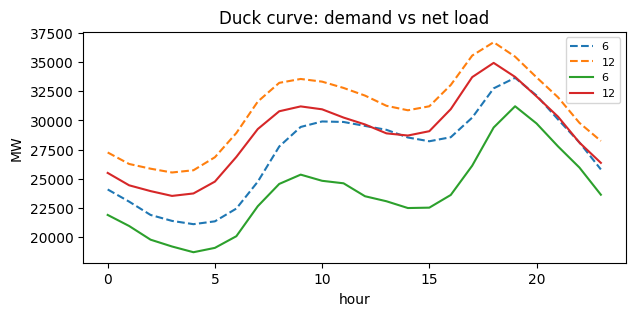

June 13:00 gap between demand and net load (MW): 6120


In [19]:
df["net_load_mw"] = df["consumption_mwh"] - df["wind_mw"] - df["solar_mw"]   # MWh per hour == average MW
june_dec = df[df["month"].isin([6, 12])]
duck = june_dec.groupby(["month", "hour"])[["consumption_mwh", "net_load_mw"]].mean().unstack("month")
fig, ax = plt.subplots(figsize=(7, 3))
duck["consumption_mwh"].plot(ax=ax, style="--", label=["demand Jun", "demand Dec"])
duck["net_load_mw"].plot(ax=ax, label=["net load Jun", "net load Dec"])
ax.set_ylabel("MW"); ax.set_title("Duck curve: demand vs net load"); ax.legend(fontsize=8)
plt.show()
print("June 13:00 gap between demand and net load (MW):", round(duck["consumption_mwh"][6].loc[13] - duck["net_load_mw"][6].loc[13]))

## 3. Residual load and price: the merit order

Price is set by the most expensive unit needed to cover net load. Bin net load and average
price inside each bin: that is the supply curve, with no model assumptions. Six hours:

In [20]:
toy = pd.DataFrame({"net_load_gw": [10, 12, 21, 23, 31, 33], "price": [40, 44, 80, 84, 150, 160]})
toy["bin"] = pd.cut(toy["net_load_gw"], bins=[0, 15, 25, 35])
toy

,net_load_gw,price,bin
0,10,40,"(0, 15]"
1,12,44,"(0, 15]"
2,21,80,"(15, 25]"
3,23,84,"(15, 25]"
4,31,150,"(25, 35]"
5,33,160,"(25, 35]"


In [21]:
curve = toy.groupby("bin", observed=True)["price"].mean()
curve

bin
(0, 15]      42.0
(15, 25]     82.0
(25, 35]    155.0
Name: price, dtype: float64

Each bin's mean price is one point of the supply curve: ~42 at 10 GW, ~82 at 22 GW, ~155 at
32 GW. The slope between bins is the price sensitivity (EUR/MWh per GW). On the real data:

In [22]:
df["resid_gw"] = df["net_load_mw"] / 1000
bins = pd.cut(df["resid_gw"], bins=np.arange(0, 45, 2.5))
curve = df.groupby(bins, observed=True).agg(price=("price_eur_mwh", "mean"), n=("price_eur_mwh", "size"))
curve.index = [b.mid for b in curve.index]
curve.round(1).T

,8.75,11.25,13.75,16.25,18.75,21.25,23.75,26.25,28.75,31.25,33.75,36.25,38.75,41.25
price,22.9,43.7,42.7,49.2,61.3,72.2,81.9,94.2,109.2,124.1,138.1,150.5,164.6,195.1
n,10.0,34.0,167.0,411.0,910.0,2018.0,2906.0,3629.0,3019.0,2344.0,1459.0,517.0,91.0,5.0


In [23]:
well_populated = curve[curve["n"] >= 100]
mids = well_populated.index.values
prices = well_populated["price"].values
slope = np.diff(prices) / np.diff(mids)
print("well-populated bins run from", mids.min(), "to", mids.max(), "GW")
print("price sensitivity (EUR/MWh per GW) low / mid / high:", np.round(slope[[0, len(slope) // 2, -1]], 1))

well-populated bins run from 13.75 to 36.25 GW
price sensitivity (EUR/MWh per GW) low / mid / high: [2.6 4.9 5. ]


### 2022 vs 2023

Same binning per year. A parallel shift means the fuel (gas) cost changed; a change in slope
means the fleet mix changed.

In [24]:
by_year = {}
for y in [2022, 2023]:
    sub = df[df["year"] == y]
    b = pd.cut(sub["resid_gw"], bins=np.arange(0, 45, 5))
    by_year[y] = sub.groupby(b, observed=True)["price_eur_mwh"].mean().round(1)
tab = pd.DataFrame(by_year)
tab.index = [b.mid for b in tab.index]
tab["shift_2023_minus_2022"] = (tab[2023] - tab[2022]).round(1)
tab

,2022,2023,shift_2023_minus_2022
7.5,57.1,0.1,-57.0
12.5,57.8,21.7,-36.1
17.5,75.7,36.4,-39.3
22.5,94.9,59.7,-35.2
27.5,115.9,86.8,-29.1
32.5,140.0,119.6,-20.4
37.5,157.2,148.2,-9.0


**Interview check:** "The curve moved down between years. Fuel or merit order?" The shift is
*not* parallel: large at low residual load, small at high. Before concluding the merit order
steepened, check composition: which months and hours fall into each bin differ by year, and
the 2022 gas spike peaked in late summer when residual load is low. Fitting price on residual
load *and* a gas proxy per year separates the two.

## 4. Price statistics

Power prices are skewed, fat-tailed, spiky and occasionally negative. Look at the tails before
choosing a model or a metric.

In [25]:
from scipy import stats
p = df["price_eur_mwh"]
print("mean", round(p.mean(), 1), " median", round(p.median(), 1), " sd", round(p.std(), 1))
print("skew", round(stats.skew(p), 2), " excess kurtosis", round(stats.kurtosis(p), 2))
print("quantiles:")
print(p.quantile([0.001, 0.01, 0.5, 0.99, 0.999]).round(1))
print("negative hours:", (p < 0).sum(), " hours above 250:", (p > 250).sum())

mean 98.5  median 97.7  sd 36.9
skew 0.41  excess kurtosis 1.94
quantiles:
0.001    -11.3
0.010     17.9
0.500     97.7
0.990    183.7
0.999    293.6
Name: price_eur_mwh, dtype: float64
negative hours: 43  hours above 250: 34


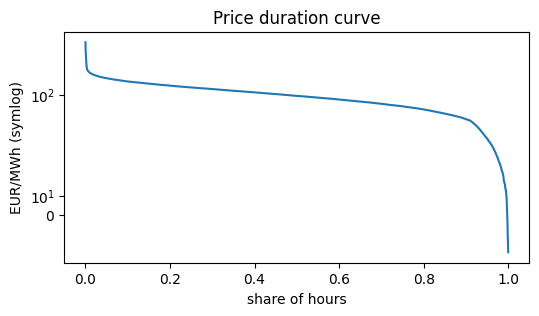

In [26]:
pdur = np.sort(p.values)[::-1]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(1, len(pdur) + 1) / len(pdur), pdur)
ax.set_yscale("symlog", linthresh=50)
ax.set_xlabel("share of hours"); ax.set_ylabel("EUR/MWh (symlog)"); ax.set_title("Price duration curve")
plt.show()

### Spike definitions

Three defensible definitions give three answers. Eight prices:

In [27]:
px = pd.Series([80, 90, 85, 400, 95, 88, 92, 250])
threshold_fixed = px.mean() + 2 * px.std()
threshold_quantile = px.quantile(0.75)
print("mean + 2 sd threshold :", round(threshold_fixed, 1))
print("75th percentile       :", round(threshold_quantile, 1))
pd.DataFrame({"price": px, "spike_fixed": px > threshold_fixed, "spike_quantile": px > threshold_quantile})

mean + 2 sd threshold : 381.0
75th percentile       : 133.8


,price,spike_fixed,spike_quantile
0,80,False,False
1,90,False,False
2,85,False,False
3,400,True,True
4,95,False,False
5,88,False,False
6,92,False,False
7,250,False,True


The fixed threshold is pulled up by the spikes themselves (400 inflates the sd) so it catches
only the biggest one; the quantile rule catches both. On the real data, with a third rule
relative to the previous 30 days:

In [28]:
spike_fixed = p > p.mean() + 3 * p.std()
spike_quantile = p > p.quantile(0.99)
previous_30d = p.rolling("30D").mean().shift(1)
spike_rolling = p > 2 * previous_30d
spikes = pd.DataFrame({"fixed": spike_fixed, "quantile": spike_quantile, "rolling": spike_rolling})
print("spike count by definition:")
print(spikes.sum())
print()
print("share of each definition's spikes that fall in 2022:")
print((spikes[df["year"] == 2022].sum() / spikes.sum()).round(2))

spike count by definition:
fixed        54
quantile    176
rolling     110
dtype: int64

share of each definition's spikes that fall in 2022:
fixed       0.54
quantile    0.77
rolling     0.23
dtype: float64


In [29]:
spike_rolling.groupby(df["hour"]).sum().rename("rolling-definition spikes by hour").to_frame().T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
rolling-definition spikes by hour,0,4,0,2,3,0,3,3,0,4,4,2,1,1,4,3,1,1,9,31,17,11,3,3


### Negative prices: what precedes them?

Compare the system in negative-price hours with all hours:

In [30]:
neg = p < 0
cols = ["consumption_mwh", "wind_mw", "solar_mw", "resid_gw"]
comparison = pd.DataFrame({"negative_hours": df.loc[neg, cols].mean(), "all_hours": df[cols].mean()}).round(0)
comparison["ratio"] = (comparison["negative_hours"] / comparison["all_hours"]).round(2)
comparison

,negative_hours,all_hours,ratio
consumption_mwh,26921.0,29315.0,0.92
wind_mw,3635.0,2079.0,1.75
solar_mw,997.0,664.0,1.50
resid_gw,22.0,27.0,0.81


Wind is well above average and residual load well below: negative prices happen when
renewables exceed what the system can absorb.

### Hourly profile, block prices, spreads

Day-ahead markets trade standard blocks: baseload = all 24 hours, peak = 07:00–19:00 local.
One toy day of 6 hours (3 "peak", 3 "off-peak"):

In [31]:
day = pd.DataFrame({"hour": [2, 4, 6, 10, 14, 18], "price": [50, 45, 60, 100, 90, 140]})
day["block"] = np.where(day["hour"].between(7, 18), "peak", "offpeak")
day

,hour,price,block
0,2,50,offpeak
1,4,45,offpeak
2,6,60,offpeak
3,10,100,peak
4,14,90,peak
5,18,140,peak


In [32]:
print("baseload (mean of all)   :", round(day["price"].mean(), 1))
print("peak block mean          :", round(day.loc[day["block"] == "peak", "price"].mean(), 1))
print("off-peak block mean      :", round(day.loc[day["block"] == "offpeak", "price"].mean(), 1))
print("peak - offpeak spread    :", round(day.loc[day["block"] == "peak", "price"].mean() - day.loc[day["block"] == "offpeak", "price"].mean(), 1))

baseload (mean of all)   : 80.8
peak block mean          : 110.0
off-peak block mean      : 51.7
peak - offpeak spread    : 58.3


A 4-hour battery earns roughly the top-4-hours mean minus the bottom-4-hours mean each day.
On the toy day with k = 2:

In [33]:
sorted_prices = np.sort(day["price"].values)
print("bottom 2:", sorted_prices[:2], " top 2:", sorted_prices[-2:])
print("battery 2h spread:", sorted_prices[-2:].mean() - sorted_prices[:2].mean())

bottom 2: [45 50]  top 2: [100 140]
battery 2h spread: 72.5


In [34]:
hour_profile = p.groupby(df["hour"]).mean().round(1)
hour_profile.rename("mean price by local hour").to_frame().T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mean price by local hour,85.8,81.0,74.6,72.0,71.6,75.1,84.5,98.7,106.6,107.6,104.8,98.7,94.3,90.4,89.3,90.6,99.0,117.1,133.3,139.2,130.7,118.9,106.5,94.3


In [35]:
by_day = df.groupby(df.index.date)
base = by_day["price_eur_mwh"].mean()
is_peak = (df["hour"] >= 7) & (df["hour"] < 19)
peak = df[is_peak].groupby(df[is_peak].index.date)["price_eur_mwh"].mean()
offpeak = df[~is_peak].groupby(df[~is_peak].index.date)["price_eur_mwh"].mean()
blocks = pd.DataFrame({"base": base, "peak": peak, "offpeak": offpeak})
blocks.index = pd.to_datetime(blocks.index)
blocks["peak_minus_offpeak"] = blocks["peak"] - blocks["offpeak"]
blocks.resample("QE").mean().round(1)

,base,peak,offpeak,peak_minus_offpeak
2022-03-31,100.9,109.6,92.3,17.3
2022-06-30,93.3,91.5,95.0,-3.5
2022-09-30,121.1,122.1,120.1,2.0
2022-12-31,133.3,141.6,125.1,16.5
2023-03-31,110.0,117.4,102.6,14.8
2023-06-30,71.2,69.8,72.5,-2.7
2023-09-30,67.4,68.3,66.5,1.8
2023-12-31,90.9,99.9,82.0,18.0


**Pitfall:** the 07–19 "peak" block is *cheaper* than off-peak in Q2 and Q3. The price peak
sits at 17–21 local and midday is depressed by solar, so a standard daytime block does not
capture the shape premium in summer. Define blocks from the data's own profile.

In [36]:
def top_bottom_spread(prices, k=4):
    s = np.sort(prices.values)
    return s[-k:].mean() - s[:k].mean()

battery = by_day["price_eur_mwh"].apply(top_bottom_spread)
battery.index = pd.to_datetime(battery.index)
print("battery 4h spread, EUR/MWh per day: mean", round(battery.mean(), 1), " median", round(battery.median(), 1))
print("mean by year:")
print(battery.groupby(battery.index.year).mean().round(1))

battery 4h spread, EUR/MWh per day: mean 73.1  median 71.0
mean by year:
2022    72.7
2023    73.6
Name: price_eur_mwh, dtype: float64


**Interview check:** "The price level fell by a third from 2022 to 2023 but the battery spread
did not move. Why?" Level is set by gas; the intraday spread is set by the *shape* of residual
load and the slope of the merit order where it sits. A battery earns the spread, so its
revenue is nearly regime-independent here, while a generator's is not.

## 5. Weather sensitivity of demand

Bin temperature and average consumption per bin. The kink at the heating threshold is the
most important non-linearity in a demand model. Degree days linearise it. Five temperatures:

In [37]:
t = pd.Series([-5, 5, 15, 20, 26], name="temp_c")
hdd = (15 - t).clip(lower=0)        # heating degrees below 15
cdd = (t - 22).clip(lower=0)        # cooling degrees above 22
pd.DataFrame({"temp_c": t, "hdd": hdd, "cdd": cdd})

,temp_c,hdd,cdd
0,-5,20,0
1,5,10,0
2,15,0,0
3,20,0,0
4,26,0,4


Below 15 °C only `hdd` is active, above 22 °C only `cdd`; between them both are zero. On the
real data:

In [38]:
tbin = pd.cut(df["temp_c"], bins=np.arange(-8, 30, 2))
sensitivity = df.groupby(tbin, observed=True)["consumption_mwh"].mean()
sensitivity.index = [b.mid for b in sensitivity.index]
sensitivity.round(0).rename("mean MW by temperature bin").to_frame().T

,-7.0,-5.0,-3.0,-1.0,1.0,3.0,5.0,7.0,9.0,11.0,13.0,15.0,17.0,19.0,21.0,23.0,25.0,27.0
mean MW by temperature bin,29649.0,30291.0,30192.0,29975.0,30682.0,31127.0,30971.0,30808.0,29604.0,28000.0,27217.0,27055.0,28139.0,29110.0,29801.0,29738.0,30359.0,29051.0


In [39]:
df["hdd"] = (15 - df["temp_c"]).clip(lower=0)
df["cdd"] = (df["temp_c"] - 22).clip(lower=0)
df[["temp_c", "hdd", "cdd"]].corrwith(df["consumption_mwh"]).round(3).rename("corr with consumption")

temp_c   -0.221
hdd       0.263
cdd       0.013
Name: corr with consumption, dtype: float64

**Pitfall:** raw hourly bins mix hours of the day (warm afternoons carry high demand for
reasons unrelated to temperature), so the raw correlation looks weaker than the effect is.
Daily means by season show the kink more clearly:

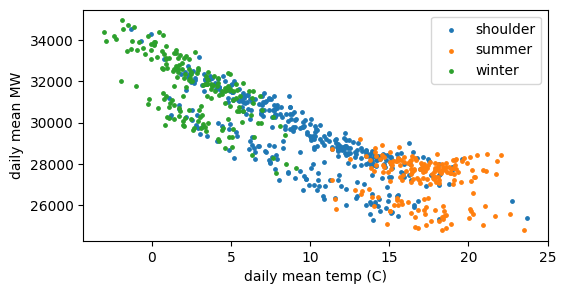

In [40]:
daily = df.resample("D").agg(cons=("consumption_mwh", "mean"), temp=("temp_c", "mean"))
is_winter = daily.index.month.isin([12, 1, 2])
is_summer = daily.index.month.isin([6, 7, 8])
daily["season"] = np.select([is_winter, is_summer], ["winter", "summer"], "shoulder")
fig, ax = plt.subplots(figsize=(6, 3))
for season, g in daily.groupby("season"):
    ax.scatter(g["temp"], g["cons"], s=6, label=season)
ax.set_xlabel("daily mean temp (C)"); ax.set_ylabel("daily mean MW"); ax.legend()
plt.show()

## 6. Data-quality checks specific to market data

Ask these *before* the statistics; a wrong answer to any of them invalidates everything after.

| Check | How | Why it bites |
|---|---|---|
| Units | `describe()`; compare to a known number (GB demand ≈ 30 GW) | MW vs MWh vs GWh; a ×1000 error looks like a regime change |
| Sign convention | count negatives per column | generation positive / export negative, or the reverse |
| Timezone of delivery periods | `df.index.tz`; the demand peak should sit at 17–19 local all year | UTC vs local shifts the peak by an hour in summer |
| Settlement vs clock time | 46 / 48 / 50 periods on DST days | half-hourly periods are not clock half-hours on two days a year |
| Price granularity | `diff().value_counts()` of timestamps | resampling prices by `mean` vs volume-weighting changes the answer |
| Interval labelling | does the timestamp mark the start or end of the delivery hour? | a one-hour offset between price and load ruins every lag |
| Missing vs zero | `(x == 0).sum()` vs `isna().sum()` | zero wind at night is real; zero demand is missing data |

In [41]:
cols = ["consumption_mwh", "wind_mw", "solar_mw", "price_eur_mwh"]
pd.DataFrame({"min": df[cols].min(), "max": df[cols].max(), "zeros": (df[cols] == 0).sum(), "negatives": (df[cols] < 0).sum()}).round(1)

,min,max,zeros,negatives
consumption_mwh,18092.9,40824.9,0,0
wind_mw,0.0,10000.0,646,0
solar_mw,0.0,5403.3,9490,0
price_eur_mwh,-19.9,419.6,0,43


In [42]:
print("timezone:", df.index.tz)
print("time steps:")
print(df.index.to_series().diff().value_counts().head(3))

timezone: Europe/London
time steps:
time
0 days 01:00:00    17519
Name: count, dtype: int64


In [43]:
peak_hour = {}
for quarter, g in df.groupby(df.index.quarter):
    peak_hour[quarter] = g.groupby("hour")["consumption_mwh"].mean().idxmax()
pd.Series(peak_hour, name="demand peak hour (local) by quarter")

1    18
2    19
3    19
4    18
Name: demand peak hour (local) by quarter, dtype: int32

## 7. Market EDA checklist

1. Units, signs, timezone, interval labelling, settlement periods: settle these first.
2. Turn weather into generation with an explicit curve; state capacity and derating.
3. Capacity factors by month and hour; duration curves; ramps; hours at zero and at rated.
4. Net load = demand − wind − solar; its shape (duck curve) drives price shape.
5. Bin price against residual load: slope = sensitivity; parallel shift = fuel.
6. Price tails: skew, kurtosis, negatives, spike counts under a stated definition.
7. Which regime does the sample cover? A 2022-style year dominates any fixed threshold.
8. Block prices and spreads: level and shape are different risks with different drivers.
9. Demand vs temperature: locate the kink; use degree days.
10. Write down what you *assumed* (curve, capacity, thresholds) so it can be challenged.